# A · From market prices to VaR and Expected Shortfall
## How much could a USD 1 million investment lose over one trading day?

Earlier lectures used company characteristics and prediction models to forecast next-month stock returns. We now consider the risk of holding an investment: how much could it lose?

We begin with a USD 1 million investment in SPY, an ETF tracking the S&P 500, then explore how combining assets changes portfolio risk.

**Prerequisites:** percentage returns, averages, standard deviations and basic Python. Allow about 120 minutes, with the portfolio extension as additional practice.

**You will be able to:**

- construct returns, P&L and losses from adjusted prices;
- compute and interpret historical and Normal VaR and Expected Shortfall;
- explain why VaR is a cutoff while Expected Shortfall measures tail severity;
- distinguish a VaR framework from a volatility estimator;
- explain rolling, EWMA and GARCH volatility; and
- state the information and assumptions behind a market-risk number.

The notebook follows one continuous chain:
$$\text{price}\rightarrow\text{return}\rightarrow\text{P\&L}\rightarrow\text{loss distribution}\rightarrow\text{VaR and ES}\rightarrow\text{portfolio risk}.$$
At each checkpoint, **predict → calculate → explain**. Worked examples have outputs; exercise cells contain a place for your own answer.

## Open and run this notebook

Keep this notebook, `requirements.txt` and the `data` folder together. The CSV is `data/market_risk_daily.csv`. Use Python 3.12 and select your course Python environment in Jupyter.

If the required packages are not already installed, run this once in a terminal from the course folder:

```text
python -m pip install -r requirements.txt
```

To open JupyterLab from that folder:

```text
python -m jupyterlab
```

Run each cell with **Shift + Enter**. After changing settings, choose **Restart Kernel and Run All Cells**. All data are read from the included CSV. This notebook contains every calculation it needs and can run independently of the other notebook.


## 1 · Know what is in the data

The supplied CSV contains daily market observations from 2015 to 2025. The ETF series were downloaded from Yahoo Finance through yfinance with price adjustment enabled. We calculate returns from these adjusted closing prices, which account for splits and distributions.

The FX and Treasury-yield series were downloaded alongside the ETFs. The supplied observations are aligned to SPY trading dates. Missing FX and yield levels were carried forward for at most three consecutive trading-date observations. Rows with unresolved gaps were removed during preparation.

Before calculating returns, check that dates are unique and chronological, required values are present, and prices are positive. The next cell performs these checks and arranges observations from oldest to newest.

| Columns | Meaning | Calculation |
|---|---|---|
| SPY, QQQ, TLT, GLD | Adjusted ETF closing prices | Simple percentage changes |
| NZDUSD | USD value of one New Zealand dollar | Percentage changes for a USD-valued NZD exposure |
| US10Y_YIELD_PCT | US 10-year Treasury yield in percentage points | First differences; multiply by 100 for basis-point changes |

SPY tracks broad US equities. QQQ tracks the Nasdaq-100, with substantial technology exposure. TLT represents long-duration US Treasury exposure, and GLD is a gold ETF proxy. Notebook A begins with **SPY only** and later combines the four ETFs.

A level must be transformed in a way that matches its economic meaning. We calculate percentage returns for traded prices and the exchange rate. The Treasury yield is already a percentage rate, so its daily risk-factor movement would normally be measured in percentage points or basis points rather than by applying pct_change(). 

NZDUSD and US10Y_YIELD_PCT are retained because later notebooks use them as market risk factors. They are inspected here but are not used in Notebook A's ETF VaR calculations.

In [1]:
import numpy as np # Numerical calculations, including square roots. 
import pandas as pd # Read the CSV and organise data in tables. 
import matplotlib.pyplot as plt # Draw charts. 
from matplotlib.ticker import PercentFormatter, StrMethodFormatter # Format chart labels. 
from IPython.display import display # Show tables in the notebook. 
from scipy.stats import norm # Normal-distribution quantiles and density. 
from arch import arch_model # Estimate a GARCH volatility model. 

# Read the local course CSV; Date is interpreted as a date rather than text. 
data = pd.read_csv("data/market_risk_daily.csv", parse_dates=["Date"]) 
data = data.set_index("Date") # Identify each row by its date. 
data = data.sort_index() # Arrange observations from oldest to newest. 

# Stop if dates are missing or repeated: both would affect daily returns. 
assert not data.index.hasnans, "Check missing or invalid dates." 
assert not data.index.has_duplicates, "Check duplicate dates." 

# Check that all required columns are present and contain finite numbers. 
required = ["SPY", "QQQ", "TLT", "GLD", "NZDUSD", "US10Y_YIELD_PCT"] 

# Identify missing columns explicitly so an error tells the student what to fix.
missing_columns = [column for column in required if column not in data.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Check that all required columns contain finite numeric values.
assert np.isfinite(data[required].to_numpy()).all(), "Check missing or invalid values." 
assert (data[["SPY", "QQQ", "TLT", "GLD", "NZDUSD"]] > 0).all().all(), "Prices must be positive." 

# Use consistent, readable chart sizes and label formats. 
plt.rcParams.update({"figure.figsize": (10, 4.5), "font.size": 11, 
                     "axes.spines.top": False, "axes.spines.right": False, 
                     "axes.grid": True, "grid.alpha": 0.2}) 
pd.set_option("display.max_columns", 12) # Show the columns in small result tables. 

# Store the table dimensions: rows are dates and columns are variables.
rows, columns = data.shape

# Display the sample period and dimensions before calculating returns.
print(f"Dates: {data.index.min().date()} to {data.index.max().date()}") 
print(f"Data dimensions: {rows:,} rows and {columns} columns")
display(data.head()) # Inspect the first five observations before calculating returns.

Dates: 2015-01-02 to 2025-12-31
Data dimensions: 2,766 rows and 6 columns


,SPY,QQQ,TLT,GLD,NZDUSD,US10Y_YIELD_PCT
Date,,,,,,
2015-01-02,169.687851,94.561142,92.287529,114.080002,0.779180,2.123
2015-01-05,166.623276,93.174057,93.737221,115.800003,0.766577,2.039
2015-01-06,165.053955,91.924767,95.426056,117.120003,0.770001,1.963
2015-01-07,167.110733,93.109772,95.237640,116.430000,0.774773,1.954
2015-01-08,170.076019,94.891846,93.976379,115.940002,0.777061,2.016


## 2 · Set the risk question

A risk number needs **positions, currency, horizon, confidence and an estimation sample**. We use USD, one trading day and 99% confidence. We will first learn the tail concept at 95% using small numbers.

The value below is a constant exposure used to convert historical returns into hypothetical dollar P&L. It is not an account whose wealth evolves through time. A realised investment backtest would compound returns and model changing holdings/value.

In [2]:
TICKER = "SPY"             # Begin with SPY; try QQQ, TLT or GLD after the first run.
VALUE = 1_000_000          # Fixed position size used to convert returns into USD P&L.
CONFIDENCE = 0.99          # A 99% confidence level leaves 1% of probability in the loss tail.
WINDOW = 500               # Use the latest 500 returns for comparable end-date estimates.
LAMBDA = 0.94              # EWMA persistence parameter; recent squared returns receive weight 1-lambda.
if TICKER not in ["SPY", "QQQ", "TLT", "GLD"]:
    raise ValueError("Choose a price series: SPY, QQQ, TLT or GLD.")
if not (VALUE > 0 and 0 < CONFIDENCE < 1 and 0 < LAMBDA < 1):
    raise ValueError("Check value, confidence and lambda.")

## 3 · Price → return → P&L → loss

For an adjusted price $P_t$, the simple return is

$$r_t=\frac{P_t}{P_{t-1}}-1.$$

Then profit and loss on a fixed position of value $V$ is

$$\text{P\&L}_t=V r_t,$$

and we define loss by reversing the sign:

$$L_t=-\text{P\&L}_t=-V r_t.$$

A gain is therefore a negative loss. A 2% return is stored as 0.02, not 2.

We apply each return to the same chosen exposure: USD 1 million by default. Each row represents a separate one-day gain-or-loss scenario. We do not compound the investment value between rows.

**Predict first:** What happens when a price rises from 100 to 102, then falls from 102 to 99? The second return is not −3%, because its starting price is 102.

In [3]:
# Create three hypothetical prices.
toy_prices = pd.Series(
    [100.0, 102.0, 99.0],
    index=["Day 0", "Day 1", "Day 2"],
)

# Calculate percentage changes without filling missing values.
toy_returns = toy_prices.pct_change(fill_method=None)

# Translate each return into P&L and loss on the chosen exposure.
worked = pd.DataFrame({
    "Price": toy_prices,
    "Return (%)": 100 * toy_returns,
    "P&L (USD)": VALUE * toy_returns,
    "Loss (USD)": -VALUE * toy_returns,
})

# Display the calculations; the first return has no preceding price.
display(worked.round(2))

# Verify the second return against the formula.
assert np.isclose(toy_returns.iloc[2], 99 / 102 - 1)

,Price,Return (%),P&L (USD),Loss (USD)
Day 0,100.0,NaN,NaN,NaN
Day 1,102.0,2.00,20000.00,-20000.00
Day 2,99.0,-2.94,-29411.76,29411.76


### Apply the same calculation to the selected ETF

We now calculate returns from the adjusted prices in the CSV.

`pct_change(fill_method=None)` calculates percentage changes without filling missing prices. The first return is unavailable because the file has no preceding price. After validating the input in Section 1, we remove that initial undefined return.

The calculations below use the selected `TICKER` and `VALUE`.

In [4]:
# Select the adjusted price series.
prices = data[TICKER]

# Calculate decimal returns and remove the initial undefined return.
returns = prices.pct_change(fill_method=None).iloc[1:].rename("Return")

# Stop if any calculated return is missing or invalid.
if not np.isfinite(returns.to_numpy()).all():
    raise ValueError("Check missing or invalid prices before proceeding.")

# Convert returns into dollar profit or loss.
pnl = VALUE * returns

# Express losses as positive numbers and gains as negative numbers.
loss = (-pnl).rename("Loss")

# Choose one date to inspect the calculation.
sample_day = returns.index[100]

# Show the inputs and outputs for that date.
display(pd.Series({
    "Date": sample_day.date(),
    "Previous adjusted price": prices.shift(1).loc[sample_day],
    "Current adjusted price": prices.loc[sample_day],
    "Return (%)": 100 * returns.loc[sample_day],
    "P&L (USD)": pnl.loc[sample_day],
    "Loss (USD)": loss.loc[sample_day],
}))

# Report the number of usable returns.
print(f"{len(returns):,} daily returns from {len(prices):,} prices.")

Date                        2015-05-29
Previous adjusted price     176.278107
Current adjusted price      175.182861
Return (%)                   -0.621317
P&L (USD)                 -6213.167254
Loss (USD)                 6213.167254
dtype: object

2,765 daily returns from 2,766 prices.


### Read the same market movements in three ways

The panels below share the same date axis:

1. **Adjusted price:** the ETF's historical adjusted level.
2. **Daily return:** its percentage change between consecutive observations.
3. **Dollar loss:** that return applied to the chosen exposure.

A negative return becomes a positive dollar loss. A positive return becomes a negative loss—a gain.

The third panel rescales and reverses the sign of the second panel; it does not contain new market information.

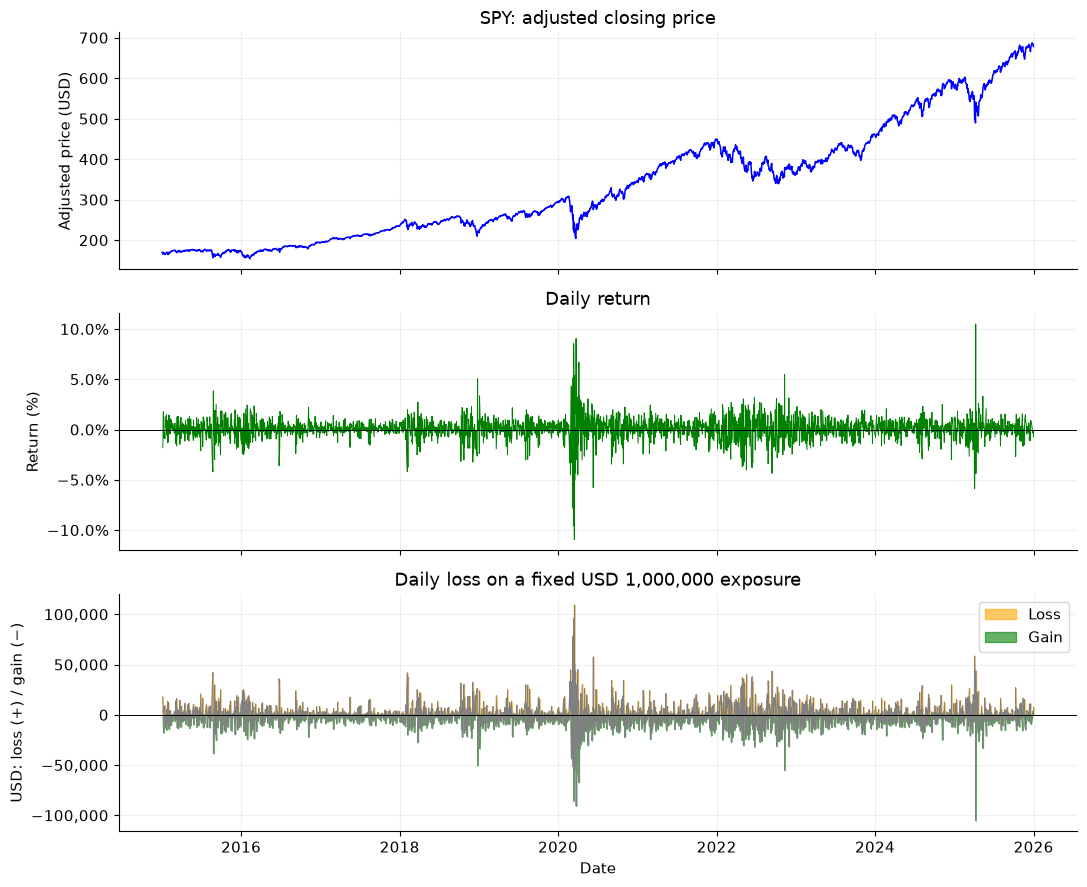

In [5]:
# Create three charts arranged vertically.
# sharex=True gives all three charts the same date axis.
# Giving each axis a descriptive name makes the remaining code easier to read.
fig, (ax_price, ax_return, ax_loss) = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

# Plot the adjusted closing price.
ax_price.plot(prices.index, prices, color="blue", linewidth=1.1)
# Add the chart title and vertical-axis label.
ax_price.set_title(f"{TICKER}: adjusted closing price")
ax_price.set_ylabel("Adjusted price (USD)")
# Show price-axis numbers with commas and no decimal places.
# For example, 1000 is displayed as 1,000.
ax_price.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

# Plot daily returns in decimal units and display the axis as percentages.
ax_return.plot(returns.index, returns, color="green", linewidth=0.7)
# Add a horizontal line at zero to separate positive and negative returns.
ax_return.axhline(0, color="black", linewidth=0.7)
# Add the chart title and vertical-axis label.
ax_return.set_title("Daily return")
ax_return.set_ylabel("Return (%)")
# Display decimal returns as percentages.
# For example, 0.02 is displayed as 2%.
ax_return.yaxis.set_major_formatter(PercentFormatter(1))

# Plot monetary losses using the same dates as the returns.
# A positive value means a loss.
# A negative value means a gain.
ax_loss.plot(loss.index, loss, color="grey", linewidth=0.6)

# Separate the loss series into the parts above and below zero.
# This does not change the data; it only prepares the two shaded areas.
positive_losses = loss.clip(lower=0)
gains = loss.clip(upper=0)

# Shade positive losses in orange.
ax_loss.fill_between(
    loss.index, 0, positive_losses,
    color="orange", alpha=0.6, label="Loss",
)

# Shade negative losses—gains—in green.
ax_loss.fill_between(
    loss.index, 0, gains,
    color="green", alpha=0.6, label="Gain",
)

# Label the monetary scale and sign convention.
ax_loss.axhline(0, color="black", linewidth=0.7)
ax_loss.set_title(f"Daily loss on a fixed USD {VALUE:,.0f} exposure")
ax_loss.set_ylabel("USD: loss (+) / gain (−)")
ax_loss.set_xlabel("Date")

# Show monetary values with commas and no decimal places.
# For example, 50000 is displayed as 50,000.
ax_loss.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

# Display the labels for the shaded loss and gain areas.
ax_loss.legend(loc="best")

# Adjust the spacing so titles and labels do not overlap.
plt.tight_layout()
# Display the completed figure.
plt.show() 

### Checkpoint 1 · Signs, units and exposure

1. Identify a large negative return in the figure. Why is the corresponding dollar loss positive?
2. For a USD 1 million exposure, what dollar loss corresponds to a −2% return?
3. If `VALUE` doubles, which panels change? What happens to dollar VaR?
4. Does a higher price level necessarily imply a higher percentage return or greater volatility?
5. Why is the first return unavailable? Why would applying `pct_change()` to an already calculated return column be wrong?

In [6]:
# Write your explanations before continuing.
answer_1 = ""

## 4 · Volatility measures size, not direction

Consider two hypothetical investments with three equally likely outcomes over the same holding period:

| Outcome | Investment A return | Investment B return |
|---|---:|---:|
| Weak market | −1% | −9% |
| Stable market | +1% | +1% |
| Strong market | +3% | +11% |
| **Expected return** | **+1%** | **+1%** |

**Think first:** Would you consider these investments equally risky just because their expected returns are equal?

Both have an expected return of 1%, but Investment B has a wider range of outcomes. For a USD 1 million investment, the weak-market scenario produces a loss of USD 10,000 for A and USD 90,000 for B.

Standard deviation measures how widely returns vary around their average. It counts both upward and downward deviations, so volatility measures variability rather than losses alone.

### Estimate volatility over a rolling window

We use the sample standard deviation of the most recent $m$ returns:

$$
\widehat{\sigma}_{t,m}
=
\sqrt{\frac{1}{m-1}
\sum_{j=0}^{m-1}(r_{t-j}-\bar r_{t,m})^2}.
$$

Here, $\bar r_{t,m}$ is the average return within that window.

- **21 observations:** approximately one trading month.
- **63 observations:** approximately three trading months.

Each observation inside the window receives equal weight. An observation receives zero weight after it leaves the window, which can cause a mechanical change in estimated volatility.

Large absolute returns often occur together. This pattern is called **volatility clustering**.

The figure reports daily volatility multiplied by $\sqrt{252}$, a conventional annualised scale. This does not establish that one-day VaR can be scaled to a year using the same rule.

These rolling estimates include the return on their labelled date. They describe volatility after that day's observation; Notebook B explains how to shift estimates when evaluating forecasts.

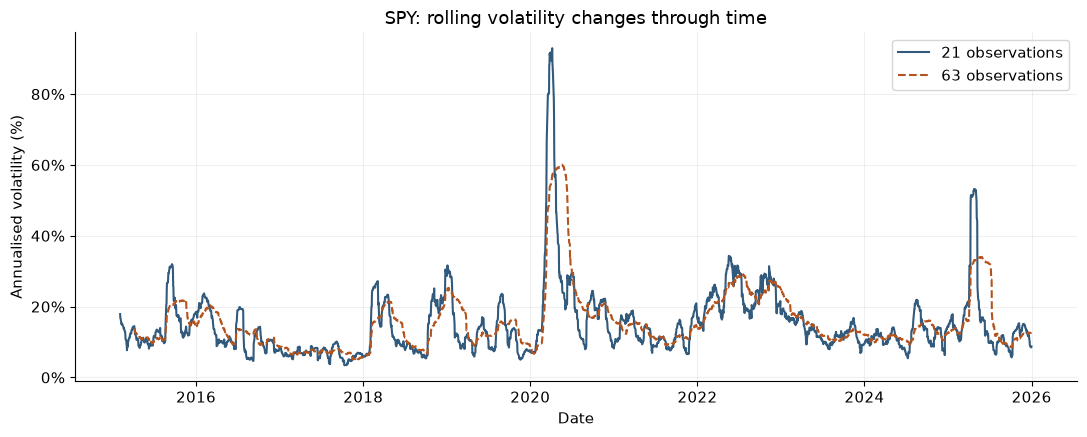

Full-sample daily volatility (%)                  1.12
Full-sample annualised volatility (%)            17.79
Worst daily loss on chosen exposure (USD)    109423.55
dtype: float64

In [7]:
# Calculate sample standard deviations over two rolling windows.
rolling = pd.DataFrame({
    "21 observations": returns.rolling(21).std(),
    "63 observations": returns.rolling(63).std(),
})

# Convert daily estimates to a conventional annualised scale.
annualised_rolling = rolling * np.sqrt(252)

# Create one figure for comparing the windows.
fig, ax = plt.subplots(figsize=(11, 4.5))

# Plot the shorter-window estimate.
ax.plot(
    annualised_rolling.index,
    annualised_rolling["21 observations"],
    color="#315a7d",
    label="21 observations",
)

# Plot the longer-window estimate with a different line style.
ax.plot(
    annualised_rolling.index,
    annualised_rolling["63 observations"],
    color="#b3541e",
    linestyle="--",
    label="63 observations",
)

# Label the selected asset and volatility scale.
ax.set_title(f"{TICKER}: rolling volatility changes through time")
ax.set_xlabel("Date")
ax.set_ylabel("Annualised volatility (%)")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend()

# Fit labels within the figure and display it.
plt.tight_layout()
plt.show()

# Summarise full-sample volatility and the largest observed scenario loss.
display(pd.Series({
    "Full-sample daily volatility (%)": 100 * returns.std(),
    "Full-sample annualised volatility (%)": 100 * returns.std() * np.sqrt(252),
    "Worst daily loss on chosen exposure (USD)": loss.max(),
}).round(2))

### Read the figure

Compare the estimates around March 2020.

- Which estimate changes more sharply?
- Which remains elevated longer?
- Could volatility fall because an old large return leaves the window, even if today's return is ordinary?

A shorter window generally gives a less stable estimate; a longer window averages over more history. Their relative responses depend on the sequence of returns entering and leaving each window.

Neither estimate tells us whether tomorrow's return will be positive or negative. The next section asks a more specific question: where does the loss tail begin, and how severe are losses within it?

## 5 · VaR is a threshold; Expected Shortfall describes tail severity

Volatility summarises the overall spread of returns, but risk managers also need to understand the loss tail.

Let $L$ denote the dollar loss over the chosen horizon and let $F_L$ denote its cumulative distribution. At confidence $c$, Value at Risk is the $c$-quantile of the loss distribution:

$$\operatorname{VaR}_c(L)=F_L^{-1}(c).$$

For a continuous loss distribution, this means

$$P\left(L\leq\operatorname{VaR}_c\right)=c, \qquad P\left(L>\operatorname{VaR}_c\right)=1-c.$$

A 99% one-day VaR of USD 20,000 means the model assigns approximately 1% probability to a loss greater than USD 20,000 over one trading day. It does **not** say that USD 20,000 is the worst possible loss. 

Expected Shortfall asks a second question: if the loss enters the worst $(1-c)$ part of the distribution, how large is the loss on average?

For continuous distributions

$$\operatorname{ES}_c=E\left[L\mid L>\operatorname{VaR}_c\right].$$

Therefore:

- **VaR identifies where the tail begins.**
- **Expected Shortfall measures the average severity of the tail.**

With discrete historical observations, a convention is required. In this notebook, every observation has equal probability. VaR uses the inverse empirical distribution, and ES averages exactly the worst $(1-c)$ probability mass. If the tail contains a fractional number of observations, the last observation receives a fractional weight.

### Calculate historical VaR and Expected Shortfall

Historical simulation treats the selected past losses as possible one-day scenarios. It does not assume that returns follow a Normal distribution.
The function below packages the calculation so we can use the same definition for a toy example, SPY and the portfolio:

`var, es = empirical_tail(losses, confidence)`

Its two inputs are the loss observations and confidence level. Its two outputs are VaR and ES in the same units as the supplied losses. Defining the function does not yet produce a risk estimate; the function must be called with data.

For example, with 250 observations and 99% confidence, the tail has probability mass equal to 2.5 observations. ES uses the two worst losses plus half of the third-worst loss, then divides by 2.5. With the default 500-observation window, the 1% tail contains five complete observations.

In [8]:
# Define the historical VaR/ES calculation here so this notebook works by itself.
def empirical_tail(losses, confidence):
    loss_values = np.asarray(losses, dtype=float)  # Convert the losses to a numeric array.
    assert loss_values.ndim == 1 and len(loss_values) > 0, "Supply a nonempty list of losses."
    assert np.isfinite(loss_values).all(), "Losses must not contain missing values."
    assert 0 < confidence < 1, "Confidence must be between zero and one."

    # Select VaR from the empirical distribution without interpolating between losses.
    var = np.quantile(loss_values, confidence, method="inverted_cdf")
    worst_first = np.sort(loss_values)[::-1]  # Put the largest loss first.
    tail_size = round(len(loss_values) * (1 - confidence), 10)  # Tail mass in observations.
    assert tail_size > 0, "Use a confidence level with nonzero tail probability."
    whole_days = int(np.floor(tail_size))  # Number of full observations in the tail.
    fraction = tail_size - whole_days  # Weight for the next observation, if needed.

    # Sum the full tail observations and add any fractional last observation.
    total_tail_loss = worst_first[:whole_days].sum()
    if fraction > 0:
        total_tail_loss = total_tail_loss + fraction * worst_first[whole_days]
    es = total_tail_loss / tail_size  # Divide by tail mass to obtain its average loss.
    return float(var), float(es)  # Return VaR first, then ES, in the input loss units.

### Why VaR does not measure the severity of extreme losses

Consider 20 equally likely daily losses, arranged from USD 1,000 to USD 20,000.

Because there are 20 observations, each observation represents 5% of the
empirical distribution:

$$\frac{1}{20}=5\%$$

At 95% confidence, the historical VaR is the 19th ordered loss:

$$\operatorname{VaR}_{95\%}=\$19{,}000$$

The worst remaining observation represents the 5% tail. Because this small
example contains only one observation in the tail, Expected Shortfall is
simply that worst loss:

$$\operatorname{ES}_{95\%}=\$20{,}000$$

Now suppose that only the worst loss increases from USD 20,000 to USD 50,000.
The first 19 observations have not changed, so the 95% VaR remains USD 19,000.
However, the loss in the worst 5% is now much larger, so ES increases to
USD 50,000.

This demonstrates an important limitation of VaR: VaR identifies where the
tail begins, but it does not measure how severe losses become beyond that
cutoff. Expected Shortfall measures the average severity of those tail losses.

With a larger sample, ES normally averages several observations. For example,
with 500 observations and 95% confidence, ES averages the worst 25 losses.

In [9]:
# Create 20 equally likely losses from USD 1,000 to USD 20,000.
toy_loss = np.arange(1, 21) * 1_000

# Create another sample where only the worst loss increases.
severe_loss = toy_loss.copy()
severe_loss[-1] = 50_000

# Calculate historical VaR and ES for both scenarios.
original_var, original_es = empirical_tail(toy_loss, 0.95)
severe_var, severe_es = empirical_tail(severe_loss, 0.95)

# Put the results in a comparison table.
toy_tail_comparison = pd.DataFrame(
    {
        "95% VaR (USD)": [original_var, severe_var],
        "95% ES (USD)": [original_es, severe_es],
    },
    index=[
        "Worst loss = $20,000",
        "Worst loss = $50,000",
    ],
)

# Display the numerical results; the column headings state the units.
display(toy_tail_comparison.round(0))

,95% VaR (USD),95% ES (USD)
"Worst loss = $20,000",19000.0,20000.0
"Worst loss = $50,000",19000.0,50000.0


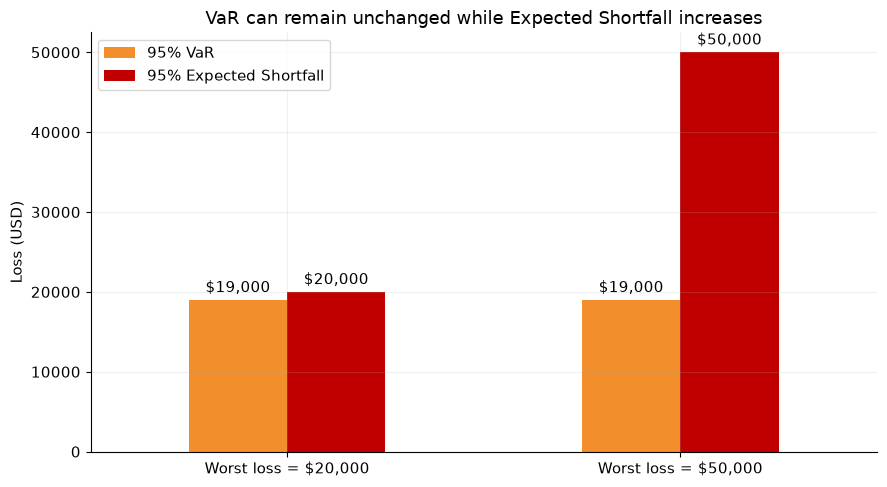

In [10]:
# Plot the values already stored in the comparison table.
ax = toy_tail_comparison.plot.bar(
    figsize=(9, 5),
    color=["#F28E2B", "#C00000"],
    rot=0,
)

# Add each value above its bar.
for bars in ax.containers:
    labels = [f"${value:,.0f}" for value in bars.datavalues]
    ax.bar_label(bars, labels=labels, padding=3)

ax.set_title("VaR can remain unchanged while Expected Shortfall increases")
ax.set_ylabel("Loss (USD)")
ax.set_xlabel("")
ax.legend(["95% VaR", "95% Expected Shortfall"])

plt.tight_layout()
plt.show()

### Apply historical VaR and ES to the selected ETF position

The toy example established the difference between a cutoff and tail severity. We now answer the notebook's central question using the latest WINDOW returns for the selected ETF.

Using one common window is important because later comparisons should differ because of the model—not because they use different dates. Historical simulation gives every observed loss in this window equal probability.

In [11]:
# Check that the requested common estimation window is valid.
if not isinstance(WINDOW, int) or WINDOW < 100 or len(returns) < WINDOW:
    raise ValueError("Choose an integer WINDOW of at least 100 within the available sample.")

# Select the latest returns once; all later risk estimates reuse these dates.
recent = returns.iloc[-WINDOW:]

# Convert the selected returns into dollar losses on the fixed exposure.
recent_losses = (-VALUE * recent).rename("Loss")

# Calculate historical VaR and Expected Shortfall.
historical_var, historical_es = empirical_tail(recent_losses, CONFIDENCE)

# State exactly which observations and assumptions produced the estimates.
print(
    f"Information ends {recent.index[-1].date()}; "
    f"{len(recent)} returns since {recent.index[0].date()}."
)
print(
    f"Position: USD {VALUE:,.0f} in {TICKER}; "
    f"horizon: one trading day; confidence: {CONFIDENCE:.1%}."
)

# Display the two historical tail measures.
historical_summary = pd.Series(
    {
        "Historical VaR (USD)": historical_var,
        "Historical Expected Shortfall (USD)": historical_es,
    }
)
display(historical_summary.to_frame("Estimate").round(2))

Information ends 2025-12-31; 500 returns since 2024-01-04.
Position: USD 1,000,000 in SPY; horizon: one trading day; confidence: 99.0%.


,Estimate
Historical VaR (USD),27027.86
Historical Expected Shortfall (USD),42114.05


### Visualise the historical risk estimates

The function returns two numbers. The next figure compares those outputs directly. Expected Shortfall is at least as large as VaR because it averages the worst `(1 − confidence)` probability mass. For discrete observations, this may include a fractional weight on an observation at the VaR cutoff.

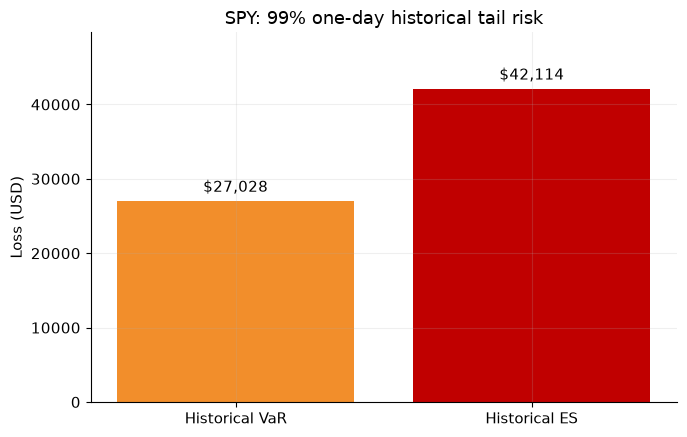

In [12]:
# Plot only the two outputs returned by the historical-tail function.
fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.bar(
    ["Historical VaR", "Historical ES"],
    [historical_var, historical_es],
    color=["#F28E2B", "#C00000"],
)

# Write the calculated dollar value above each bar.
ax.bar_label(
    bars,
    labels=[f"${historical_var:,.0f}", f"${historical_es:,.0f}"],
    padding=4,
)

ax.set_title(f"{TICKER}: {CONFIDENCE:.0%} one-day historical tail risk")
ax.set_ylabel("Loss (USD)")
ax.set_ylim(0, max(historical_var, historical_es) * 1.18)

plt.tight_layout()
plt.show()

**Checkpoint 2 ·** Interpret the historical estimates

Explain both numbers in words. Your answer should name the position, currency, horizon, confidence level and estimation window.

**Then answer:** why does Expected Shortfall provide information that VaR does not?

In [13]:
answer_2 = ""

## 6 · Parametric VaR assumes a model for returns

Historical simulation constructs the loss distribution directly from observed losses. A parametric approach instead assumes a probability distribution with a small number of parameters.

Suppose the one-day return is Normally distributed:

$$R\sim N(\mu,\sigma^2), \qquad L=-VR.$$

Let $z_c=\Phi^{-1}(c)$ be the standard-Normal quantile at confidence level $c$. It is positive when $c>0.5$, including the 95% and 99% confidence levels used here. At 99% confidence, $z_c\approx2.326$. The lower-tail return is $\mu-z_c\sigma$. Reversing its sign and multiplying by the position value gives:

$$\operatorname{VaR}_c=V(z_c\sigma-\mu).$$

For the same Normal model, Expected Shortfall is:
$$\operatorname{ES}_c=V\left[-\mu+\sigma\frac{\phi(z_c)}{1-c}\right],$$

where $\Phi^{-1}$ is the standard-Normal quantile function and $\phi$ is the standard-Normal density. This method is quick and transparent, but the result depends on whether the Normal distribution adequately represents the return distribution—especially its tails—and whether the estimated mean and volatility represent current conditions.

In [ ]:
# Calculate the probability mass beyond the VaR cutoff.
tail_probability = 1 - CONFIDENCE

# Obtain the standard-Normal quantile for the chosen confidence level.
z_c = norm.ppf(CONFIDENCE)

# Estimate the return mean and sample volatility from the same WINDOW observations.
mu = recent.mean()
sigma = recent.std()

# Apply the Normal-model formulas to the fixed position value.
normal_var = VALUE * (z_c * sigma - mu)
normal_es = VALUE * (
    -mu + sigma * norm.pdf(z_c) / tail_probability
)

# Compare historical and Normal tail estimates using the same data window.
tail_summary = pd.DataFrame(
    {
        "VaR (USD)": [historical_var, normal_var],
        "Expected Shortfall (USD)": [historical_es, normal_es],
    },
    index=["Historical", "Static Normal"],
)

display(tail_summary.round(2))

# Under the positive-loss convention, ES should not be below VaR.
assert historical_es >= historical_var - 1e-8
assert normal_es >= normal_var - 1e-8

,VaR (USD),Expected Shortfall (USD)
Historical,27027.86,42114.05
Static Normal,23155.07,26651.97


### Compare the observed losses with the fitted Normal model

The histogram shows the empirical distribution of the latest WINDOW losses. The curve shows the Normal loss distribution implied by the estimated return mean and volatility.

Probability is represented by area under the density, not by the height of a bar or curve. For example, the area to the right of a loss threshold represents the probability of exceeding that loss.

The two vertical lines compare the historical and Normal VaR cutoffs. If the Normal curve does not represent the shape of the observed right tail well, the two frameworks can produce materially different risk estimates.

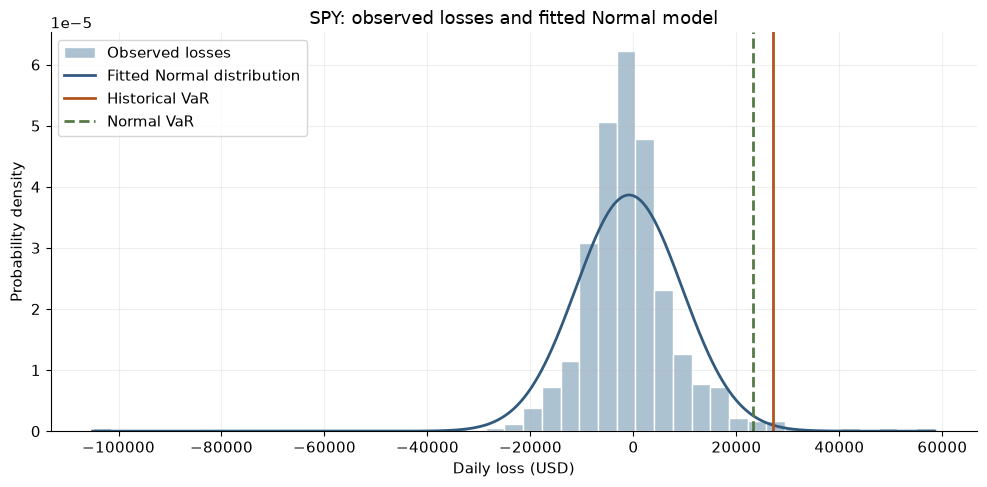

In [15]:
# Create a large, separate figure for the loss distribution.
plt.figure(figsize=(10, 5))

# Plot observed losses as a density histogram.
# density=True places the histogram and Normal curve on the same vertical scale.
plt.hist(
    recent_losses,
    bins=45,
    density=True,
    color="#adc2d1",
    edgecolor="white",
    label="Observed losses",
)

# Translate the estimated return mean and volatility into loss units.
normal_loss_mean = -VALUE * mu
normal_loss_std = VALUE * sigma

# Evaluate the fitted Normal density across the observed loss range.
loss_grid = np.linspace(recent_losses.min(), recent_losses.max(), 500)
normal_density = norm.pdf(
    loss_grid,
    loc=normal_loss_mean,
    scale=normal_loss_std,
)

# Add the fitted distribution and the two VaR cutoffs.
plt.plot(
    loss_grid,
    normal_density,
    color="#315a7d",
    linewidth=2,
    label="Fitted Normal distribution",
)
plt.axvline(
    historical_var,
    color="#b3541e",
    linewidth=2,
    label="Historical VaR",
)
plt.axvline(
    normal_var,
    color="#557a46",
    linewidth=2,
    linestyle="--",
    label="Normal VaR",
)

plt.title(f"{TICKER}: observed losses and fitted Normal model")
plt.xlabel("Daily loss (USD)")
plt.ylabel("Probability density")
plt.legend()

plt.tight_layout()
plt.show()

**Read the comparison**
The histogram need not follow the smooth Normal curve exactly; a finite sample is naturally irregular. Focus on economically meaningful differences such as asymmetry, a sharper centre, or unusually heavy tails.

Historical simulation assumes that the selected past scenarios are informative about future losses. The static Normal model instead assumes that returns are adequately described by one constant mean and volatility and a Normal shape. Neither assumption is automatically correct.

## 7 · A VaR framework and a volatility estimator are different choices 

We have now used two **VaR frameworks**:
1. **Historical simulation** constructs the loss distribution from observed losses.
2. **Parametric VaR** constructs the loss distribution from an assumed probability model.

Monte Carlo is a third framework: it generates many scenarios from a specified model and revalues the position under each scenario.

A **volatility estimator** answers a different question: how should current $\sigma$ be measured? The Normal VaR calculation above used one sample standard deviation over the entire window. Rolling windows, EWMA and GARCH provide alternative volatility estimates.

The earlier rolling-volatility chart showed that volatility changes through time. Therefore, one constant sample volatility may not represent current market conditions. We next examine EWMA and GARCH, then insert their volatility estimates into the same Normal VaR framework.

In this notebook, EWMA + Normal and GARCH + Normal are parametric VaR calculations that use the same Normal tail formula with different volatility estimates. EWMA and GARCH model variance; they do not, by themselves, require Normally distributed returns.

## 8 · EWMA gives more weight to recent shocks

Let $v_t$ be variance **after observing day t**:


$$v_t=\lambda v_{t-1}+(1-\lambda)r_t^2.$$

At lambda 0.94, the old variance gets 94% weight and today's squared return gets 6%. With previous daily volatility 1% and today's return −3%, the new variance is $0.94(0.01^2)+0.06(0.03^2)=0.000148$. Its square root is about **1.217% daily volatility**. Squaring the return means a negative and positive return of the same magnitude create the same immediate volatility shock.

Repeated substitution shows how older shocks receive declining weights:

$$v_t=\lambda^t v_0+(1-\lambda)\sum_{j=0}^{t-1}\lambda^j r_{t-j}^2,\qquad v_0=r_0^2.$$

A higher $\lambda$ makes the weights decay more slowly, so the model remembers shocks for longer. A lower $\lambda$ reacts more strongly to the newest return but forgets it faster.

In this notebook, $t-1$ means the **previous available market observation**, not necessarily the previous calendar day. A Friday observation is therefore followed by Monday when weekends contain no trading observations. Missing calendar dates do not interrupt the recursion; missing values inside the return series would.

We assume zero conditional mean. Initialise variance with the first squared return; the initialisation fades as lambda is repeatedly applied. This end-of-day estimate can forecast the **next** available observation. To compare a forecast with day $t$'s realised outcome, use information available at $t-1$.

In [16]:
# Create an empty series that will store one EWMA variance estimate per return date.
variance = pd.Series(index=returns.index, dtype=float)

# Initialise variance with the first squared return.
variance.iloc[0] = returns.iloc[0]**2

# Update variance in observation order.
# t-1 refers to the previous row in the return series, even across a weekend or holiday.
for t in range(1, len(returns)):
    previous_variance = variance.iloc[t - 1]
    current_squared_return = returns.iloc[t]**2
    variance.iloc[t] = LAMBDA * previous_variance + (1 - LAMBDA) * current_squared_return

# Take the square root to convert variance to volatility.
ewma_vol = np.sqrt(variance)

# Calculate the same recursion with pandas for a numerical cross-check.
compact_ewma = np.sqrt(returns.pow(2).ewm(alpha=1 - LAMBDA, adjust=False).mean())
assert np.allclose(ewma_vol, compact_ewma)

# Report the numerical example from the Markdown explanation.
worked_ewma_volatility = np.sqrt(0.94 * 0.01**2 + 0.06 * 0.03**2)
print(f"Worked update: {worked_ewma_volatility:.3%} daily volatility")

# Report how many observations it takes for a shock's EWMA weight to halve.
print(f"EWMA squared-shock weight half-life: {np.log(.5)/np.log(LAMBDA):.1f} observations")

Worked update: 1.217% daily volatility
EWMA squared-shock weight half-life: 11.2 observations


**Checkpoint 3.** EWMA persistence

Predict the effect of changing lambda from 0.94 to 0.90 and 0.97. Which retains a shock longer? Compare the curves around March 2020. No estimator is always “fastest”: window length, initial conditions and the shock history matter.

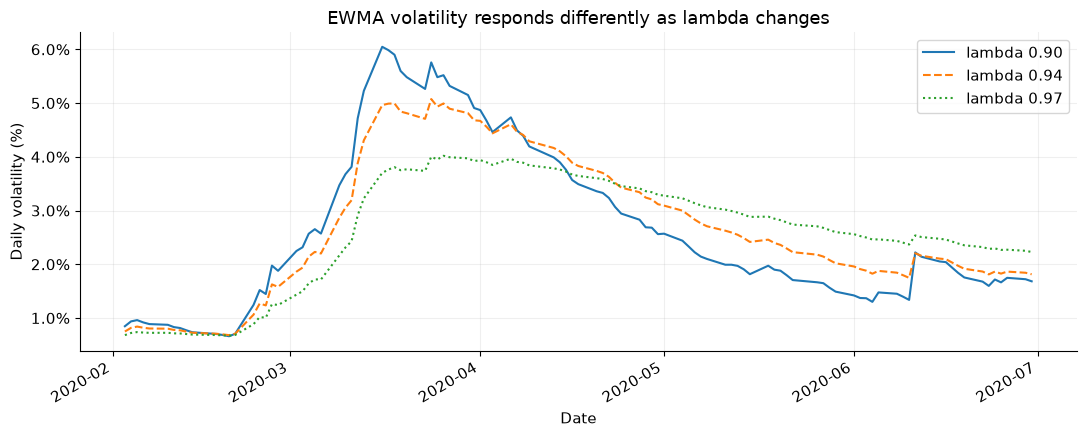

In [17]:
# Create one chart for comparing three EWMA persistence choices.
fig, ax = plt.subplots(figsize=(11, 4.5))

# Calculate and plot each EWMA series over the same market-stress period.
for lam, style in zip([0.90, 0.94, 0.97], ["-", "--", ":"]):
    volatility = np.sqrt(
        returns.pow(2).ewm(alpha=1 - lam, adjust=False).mean()
    )
    volatility.loc["2020-02":"2020-06"].plot(
        ax=ax,
        label=f"lambda {lam:.2f}",
        linestyle=style,
    )

# Label the volatility scale and identify each lambda value.
ax.set_title("EWMA volatility responds differently as lambda changes")
ax.set_xlabel("Date")
ax.set_ylabel("Daily volatility (%)")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend()

# Fit labels within the figure and display it.
plt.tight_layout()
plt.show()

## 9 · GARCH adds a mean-reverting variance model

EWMA responds to new squared returns and carries previous variance forward, but its coefficients are fixed and it has no explicit long-run variance. A GARCH(1,1) model estimates its coefficients from the data:

$$h_{t+1}=\omega+\alpha r_t^2+\beta h_t.$$

After observing return $r_t$:
- $\alpha$ controls the reaction to the newest squared return;
- $\beta$ carries forward the current variance estimate; and
- $\omega$ helps variance move back toward a long-run level.

When $\omega>0$, $\alpha,\beta\geq0$ and $\alpha+\beta<1$, the model has finite unconditional variance:

$$\overline{h}=\frac{\omega}{1-\alpha-\beta}.$$

A value of $\alpha+\beta$ close to one means that volatility shocks decay slowly.

EWMA has a similar recursion but fixes $\omega=0$, $\alpha=1-\lambda$ and $\beta=\lambda$. GARCH estimates these coefficients and includes a long-run component.

We fit a **zero-mean, normal GARCH(1,1)** using the same latest WINDOW returns. Multiplying decimal returns by 100 improves the numerical scale of estimation. The resulting variance is in percent squared, so forecast volatility is divided by 100 before it is used with decimal returns.

The filtered estimates describe the estimation sample; this is not an out-of-sample backtest. The one-step forecast estimates volatility for the next available market observation. Notebook B evaluates forecasts using outcomes that were not available when each forecast was made.

In [18]:
# Reuse the common WINDOW selected before historical VaR was calculated.
# Fit a zero-mean normal GARCH(1,1) model.
# Multiplication by 100 changes decimal returns into percentage returns for estimation.
garch = arch_model(
    recent * 100,
    mean="Zero",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal",
    rescale=False,
)
fit = garch.fit(disp="off")

# Stop if the numerical optimisation did not converge successfully.
if fit.convergence_flag != 0:
    raise RuntimeError("GARCH did not converge; investigate before using its forecast.")

# Request the next observation variance, in percent squared.
next_variance = fit.forecast(horizon=1, reindex=False).variance.iloc[-1, 0]

# Convert forecast variance to decimal daily volatility.
next_garch_vol = np.sqrt(next_variance) / 100

# Display the fitted coefficients and a simple measure of volatility persistence.
display(fit.params.to_frame("Estimate in percent-return model"))
persistence = fit.params["alpha[1]"] + fit.params["beta[1]"]
print(f"alpha + beta = {persistence:.4f}")
print(f"Next-observation daily volatility forecast: {next_garch_vol:.3%}")

,Estimate in percent-return model
omega,0.054818
alpha[1],0.121183
beta[1],0.818339


alpha + beta = 0.9395
Next-observation daily volatility forecast: 0.707%


## 10 · Compare four end-of-sample VaR estimates

We can now bring the methods together. Every estimate uses the same position value, currency, one-day horizon, confidence level, end date and WINDOW observations.

- Historical VaR uses the empirical loss distribution directly.
- Static Normal VaR uses the window's sample mean and sample volatility.
- EWMA + Normal VaR uses the final EWMA volatility and assumes zero conditional mean.
- GARCH + Normal VaR uses the next-observation GARCH volatility forecast and assumes zero conditional mean.

The comparison therefore reflects the loss framework, volatility information and—in the static model—the treatment of the mean. For one-day risk, the estimated mean is often small relative to volatility, but it should still be stated.

In [19]:
# Estimate end-of-window EWMA variance using the common WINDOW observations.
recent_ewma_variance = recent.pow(2).ewm(
    alpha=1 - LAMBDA,
    adjust=False,
).mean()

# Select the final EWMA volatility estimate.
recent_ewma_vol = np.sqrt(recent_ewma_variance.iloc[-1])

# Insert the EWMA and GARCH volatility estimates into Normal VaR.
# Both conditional models assume a zero one-day conditional mean here.
ewma_normal_var = VALUE * z_c * recent_ewma_vol
garch_normal_var = VALUE * z_c * next_garch_vol

# Collect the four estimates in the order in which they were introduced.
var_comparison = pd.Series(
    {
        "Historical": historical_var,
        "Static Normal": normal_var,
        "EWMA + Normal": ewma_normal_var,
        "GARCH + Normal": garch_normal_var,
    },
    name="One-day VaR (USD)",
)

print(
    f"Common information set: {recent.index[0].date()} to "
    f"{recent.index[-1].date()} ({len(recent)} returns)."
)
display(var_comparison.to_frame().round(2))

Common information set: 2024-01-04 to 2025-12-31 (500 returns).


,One-day VaR (USD)
Historical,27027.86
Static Normal,23155.07
EWMA + Normal,15278.01
GARCH + Normal,16436.74


### Visualise the four VaR estimates

The bars compare the final risk numbers. A difference between bars does not by itself tell us which model is correct; it shows how modelling choices affect the estimate. Notebook B introduces backtesting, which asks how risk forecasts perform against later realised losses.

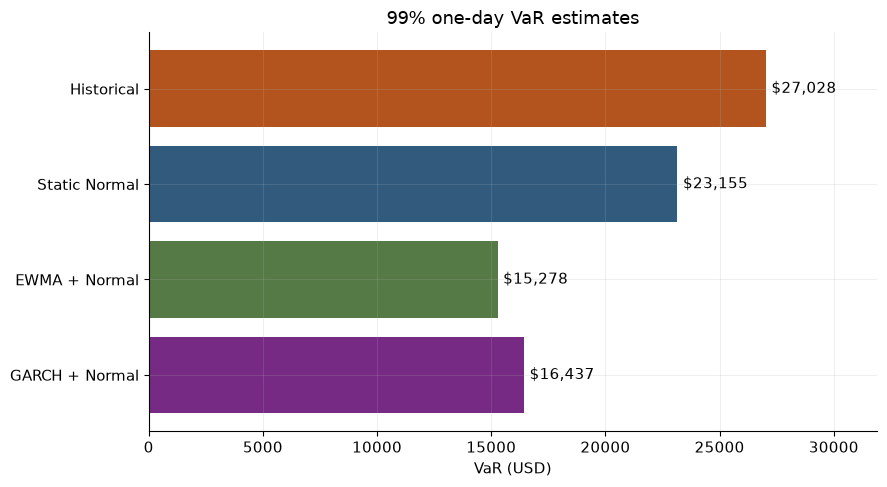

In [20]:
# Choose one colour for each VaR estimate.
bar_colors = ["#b3541e", "#315a7d", "#557a46", "#762a83"]

# Create a separate figure for comparing VaR estimates.
plt.figure(figsize=(9, 5))

# Plot the four VaR estimates.
bars = plt.barh(
    var_comparison.index,
    var_comparison.values,
    color=bar_colors,
)

# Write each dollar estimate beside its bar.
plt.bar_label(
    bars,
    labels=[f"${value:,.0f}" for value in var_comparison.values],
    padding=4,
)

# Add titles and labels.
plt.title(f"{CONFIDENCE:.0%} one-day VaR estimates")
plt.xlabel("VaR (USD)")

# Add some space so the value labels are not cut off.
plt.xlim(0, var_comparison.max() * 1.18)

plt.gca().invert_yaxis()  # Show Historical first, matching the table and teaching order.

plt.tight_layout()
plt.show()

### What changes across the estimates?

| Estimate | Loss framework | Volatility information | Main assumption or limitation |
|---|---|---|---|
| Historical | Empirical loss quantile | Each return in the window receives equal probability | The selected past window represents relevant future scenarios |
| Static normal | Normal distribution | One sample mean and standard deviation for the whole window | Returns are adequately represented by a normal distribution with constant parameters |
| EWMA + normal | Normal distribution | Recent squared returns receive more weight | Normal conditional returns and a fixed choice of $\lambda$ |
| GARCH + normal | Normal distribution | Estimated conditional variance forecast | The fitted GARCH dynamics and normal innovations describe the next observation |

Monte Carlo is another way to construct a loss distribution rather than another volatility estimator. It draws many scenarios from a specified model and revalues the position under each scenario. For one linear position with normally distributed returns, Monte Carlo should approach the same result as analytical Normal VaR as the number of simulations increases. Its flexibility becomes more valuable for several correlated risk factors or nonlinear instruments. Notebook A keeps the calculation focused on historical and parametric approaches.

**Checkpoint 4.** Explain why the estimates differ

Explain the actual VaR and ES amounts above to a client. Then repeat the calculations at 95% confidence.

Why does a 250-observation 99% historical tail contain only 2.5 observations of probability mass? Why should a risk manager distrust claims of great precision based on so few extreme observations?

In [21]:
answer_4 = ""  # Include position, currency, horizon, confidence, model and estimation sample.

## 11 · Optional extension: combine holdings

For fixed weights, portfolio return is the weighted average of the asset returns:

$$r_{p,t}=\sum_i w_i r_{i,t}=\mathbf{w}^{\top}\mathbf{r}_t.$$

For two assets, portfolio variance is

$$\sigma_p^2=w_1^2\sigma_1^2+w_2^2\sigma_2^2+2w_1w_2\rho_{12}\sigma_1\sigma_2.$$

The final term captures co-movement. If correlation is below +1, the assets do not move perfectly together and portfolio volatility can fall below the weighted average of their individual volatilities. For several assets, the same calculation becomes

$$\sigma_p=\sqrt{\mathbf{w}^{\top}\boldsymbol{\Sigma}\mathbf{w}}.$$

Covariances therefore matter: weighted individual volatilities do not add to portfolio volatility.

We apply each historical return vector to the same weights and chosen exposure (USD 1 million by default). These are fixed-exposure daily scenarios. A buy-and-hold portfolio would have drifting weights; maintaining fixed weights through time would require rebalancing. SPY and QQQ overlap: QQQ is a concentration tilt, not an independent asset class. A covariance-aware contribution to **daily dollar volatility** is $V w_i(\Sigma w)_i/\sigma_p$. These contributions sum to portfolio dollar volatility and can be negative for hedging holdings.

### Correlations explain diversification

A correlation near +1 means returns tend to move together; a lower correlation can reduce portfolio variability. These are sample estimates from the same WINDOW observations used below, not permanent relationships. SPY and QQQ overlap substantially.

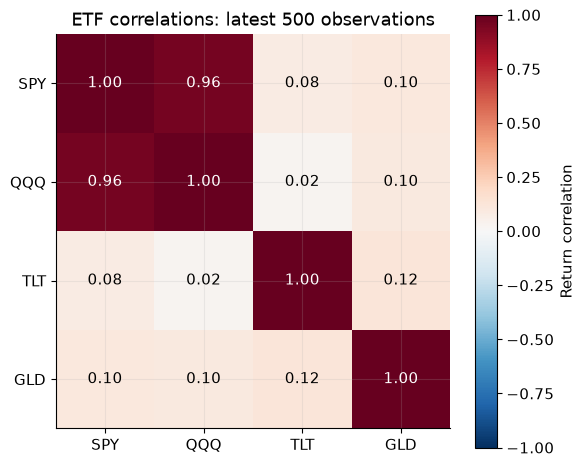

In [22]:
# Calculate daily returns for the four ETF prices.
asset_returns = data[["SPY", "QQQ", "TLT", "GLD"]].pct_change(
    fill_method=None
).iloc[1:]

# Estimate return correlations using the same final WINDOW observations.
recent_asset_returns = asset_returns.iloc[-WINDOW:]
correlation = recent_asset_returns.corr()

# Create a compact heatmap using the full correlation scale from -1 to +1.
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(correlation, vmin=-1, vmax=1, cmap="RdBu_r")

# Label the heatmap rows and columns with the ETF tickers.
positions = range(len(correlation.columns))
ax.set_xticks(positions, correlation.columns)
ax.set_yticks(positions, correlation.index)

# Write the estimated correlation inside every heatmap cell.
for row in positions:
    for column in positions:
        estimate = correlation.iloc[row, column]
        text_color = "white" if abs(estimate) > 0.6 else "black"
        ax.text(
            column,
            row,
            f"{estimate:.2f}",
            ha="center",
            va="center",
            color=text_color,
        )

# Add the colour scale and identify the estimation window.
fig.colorbar(image, ax=ax, label="Return correlation")
ax.set_title(f"ETF correlations: latest {WINDOW} observations")

# Fit labels within the figure and display it.
plt.tight_layout()
plt.show()

In [23]:
# Define fixed portfolio weights.
weights = pd.Series({"SPY": 0.50, "QQQ": 0.20, "TLT": 0.20, "GLD": 0.10})

# Check that this long-only portfolio is fully invested.
assert np.isclose(weights.sum(), 1) and (weights >= 0).all()

# Select the corresponding ETF returns and the common estimation window.
asset_returns = data[weights.index].pct_change(fill_method=None).iloc[1:]
recent_asset_returns = asset_returns.iloc[-WINDOW:]

# Combine asset returns using the portfolio weights.
portfolio_returns = asset_returns @ weights

# Estimate how the asset returns move together.
covariance = recent_asset_returns.cov()

# Calculate portfolio volatility using weights and covariances.
portfolio_sigma = np.sqrt(weights @ covariance @ weights)

# Calculate the weighted average of individual volatilities for comparison.
# This ignores diversification because it does not include correlations.
weighted_individual_sigma = weights @ recent_asset_returns.std()
diversification_reduction = weighted_individual_sigma - portfolio_sigma

# Allocate dollar volatility using covariance-aware contributions.
contributions = VALUE * weights * (covariance @ weights) / portfolio_sigma
assert np.isclose(contributions.sum(), VALUE * portfolio_sigma)

# Calculate the combined portfolio historical VaR and ES.
portfolio_losses = -VALUE * portfolio_returns.iloc[-WINDOW:]
portfolio_var, portfolio_es = empirical_tail(portfolio_losses, CONFIDENCE)

# Display weights and each holding's contribution to daily dollar volatility.
display(
    pd.DataFrame(
        {
            "Weight": weights,
            "Daily volatility contribution (USD)": contributions,
        }
    ).round(3)
)

# Display portfolio volatility, the diversification comparison, VaR and ES.
display(
    pd.Series(
        {
            "Weighted individual daily volatility (%)": 100 * weighted_individual_sigma,
            "Portfolio daily volatility (%)": 100 * portfolio_sigma,
            "Diversification reduction (percentage points)": 100 * diversification_reduction,
            "Portfolio historical VaR (USD)": portfolio_var,
            "Portfolio historical ES (USD)": portfolio_es,
        }
    ).round(2)
)
# Note that the displayed values are independently rounded: subtracting the two displayed two-decimal values may not reproduce the separately rounded reduction.

,Weight,Daily volatility contribution (USD)
SPY,0.5,4987.758
QQQ,0.2,2487.260
TLT,0.2,454.701
GLD,0.1,282.882


Weighted individual daily volatility (%)             1.06
Portfolio daily volatility (%)                       0.82
Diversification reduction (percentage points)        0.23
Portfolio historical VaR (USD)                   20736.03
Portfolio historical ES (USD)                    31585.74
dtype: float64

## 12 · The complete risk-measurement chain

Notebook A has followed one question from raw data to a portfolio risk estimate:
| Step | Calculation | Question answered |
|---|---|---|
| 1. Market level | Adjusted price $P_t$ | What adjusted price level is recorded? |
| 2. Market movement | $r_t=P_t/P_{t-1}-1$ | How much did its value change? |
| 3. Dollar outcome | $L_t=-Vr_t$ | What would that movement mean for our position? |
| 4. Tail measurement | VaR and Expected Shortfall | Where does the loss tail begin, and how severe is it? |
| 5. Model choice | Historical or Normal; static, EWMA or GARCH volatility | Which information and assumptions generate the risk number? |
| 6. Portfolio aggregation | $r_{p,t}=\mathbf{w}^{\top}\mathbf{r}_t$ | How do weights and co-movement change total risk? |

A VaR number is therefore never self-explanatory. A complete statement must identify the position, currency, horizon, confidence level, estimation sample and model.

## 13 · Practice

1. **Core:** change SPY to TLT; explain what the asset change means before comparing results.
2. **Core:** double VALUE. Identify which outputs double and which stay unchanged.
3. **Core:** compare WINDOW = 250 and 500. Keep the confidence and end date fixed.
4. **Extension:** compare the mixed portfolio with 100% SPY. Distinguish sample findings from a claim that diversification always protects against every shock.

Write a five-sentence conclusion: risk question, VaR meaning, ES meaning, model difference, limitation. Do not present a low VaR as automatically desirable or reliable.

**Next: Notebook B.** It asks whether forecasts hold up against outcomes that had not yet occurred, then applies the same ideas to a bank trading book. B runs independently; you do not need A's variables in memory.

### Optional reading

- [RiskMetrics Technical Document (1996)](https://www.msci.com/documents/10199/5915b101-4206-4ba0-aee2-3449d5c7e95a): EWMA background. Ask why lambda is a modelling choice.
- [Bollerslev (1986), GARCH](https://scholars.duke.edu/publication/651658): the variance-model foundation. Focus on the recursion and persistence.
- [MIT OCW, Kenneth Abbott: Value At Risk Models](https://ocw.mit.edu/courses/18-s096-topics-in-mathematics-with-applications-in-finance-fall-2013/resources/lecture-7-value-at-risk-var-models/): optional video context, not required to run this lab.